Name:Soham Thakre

Class:B_B1

Roll no:09

ML PRAC 4

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WineQT.xls to WineQT.xls


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [ ]:
df=pd.read_csv('WineQT.xls')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

Univariate Ananlysis

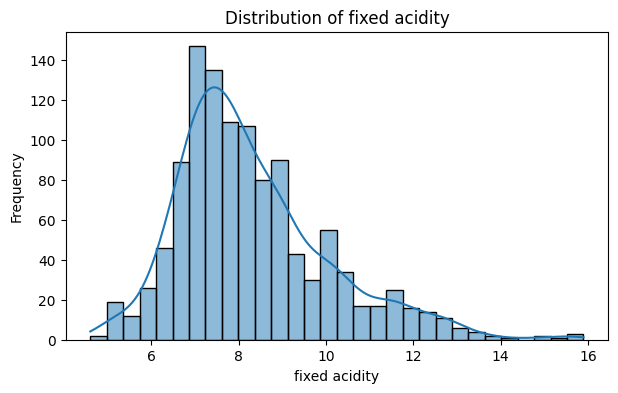

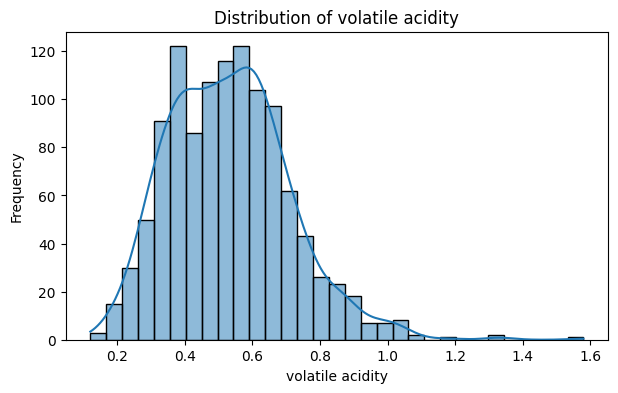

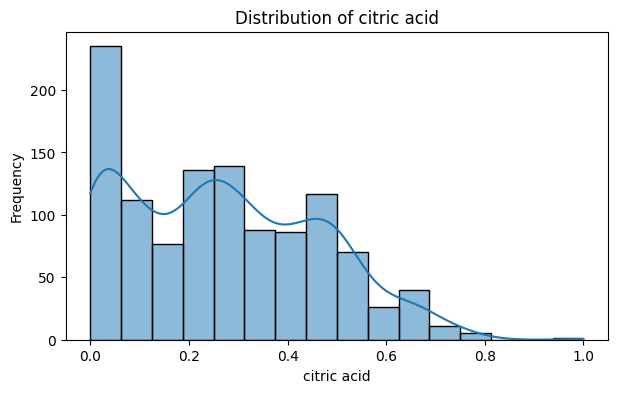

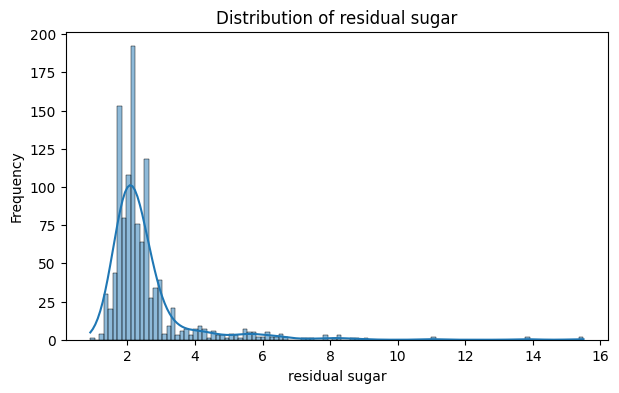

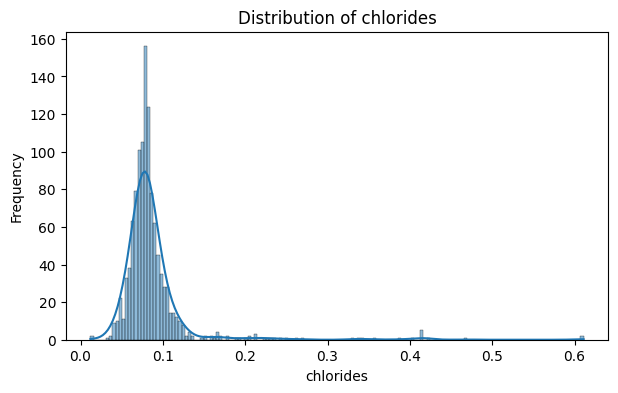

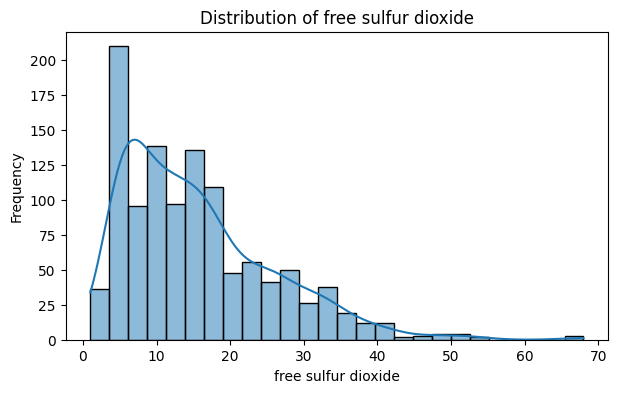

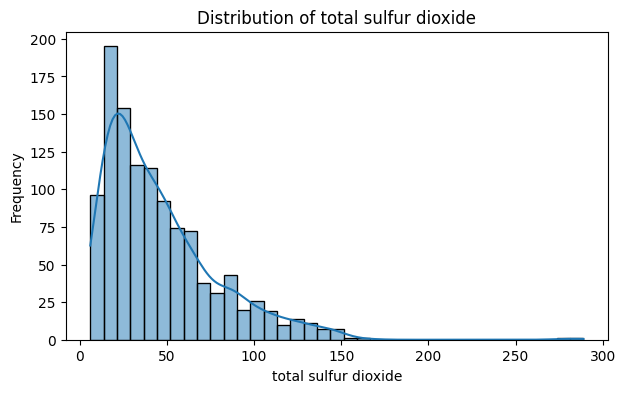

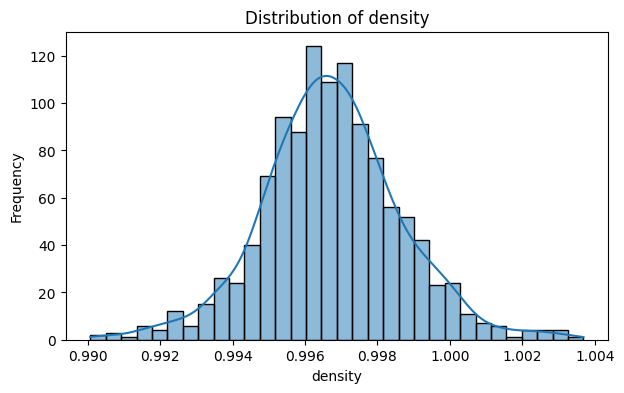

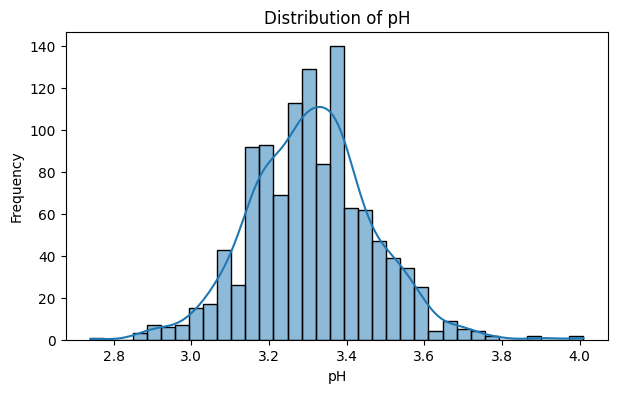

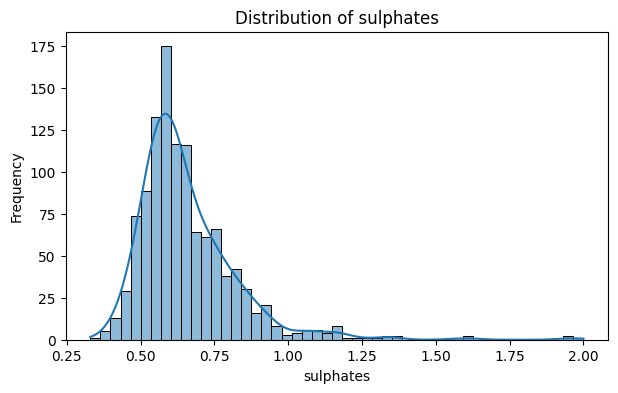

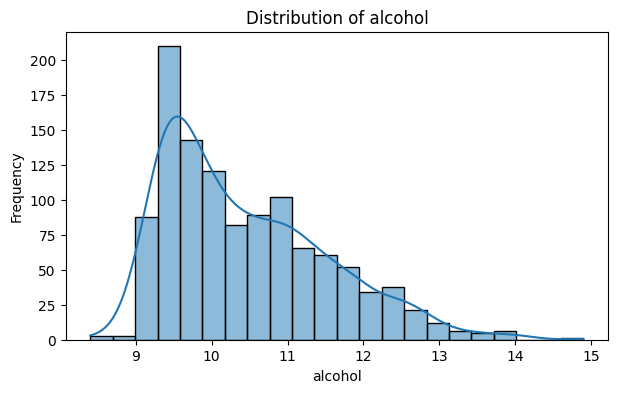

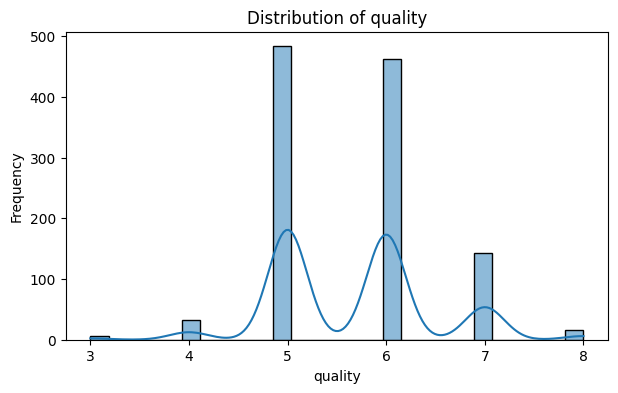

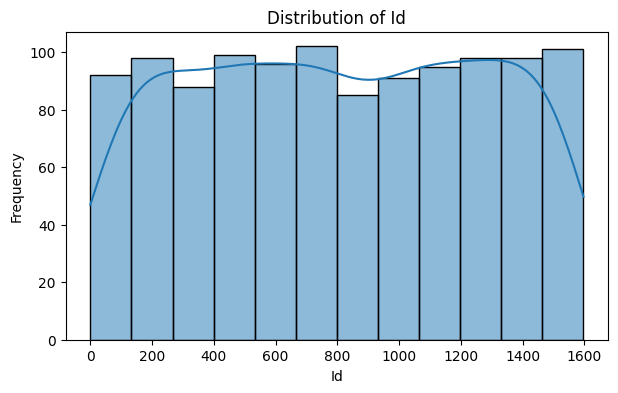

In [ ]:
#Histogram+KDE
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols=df.columns

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

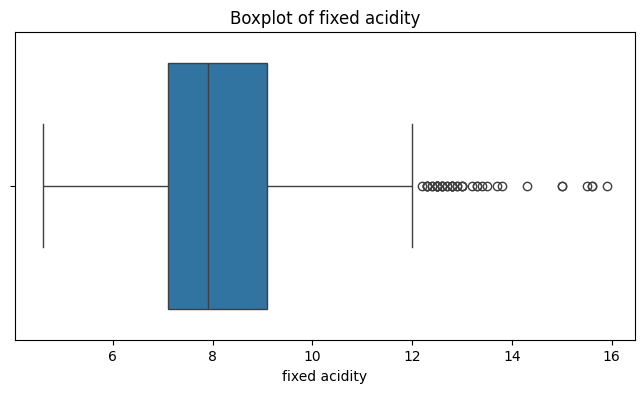

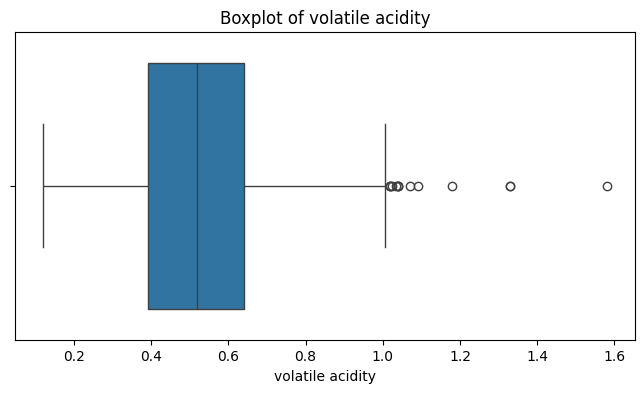

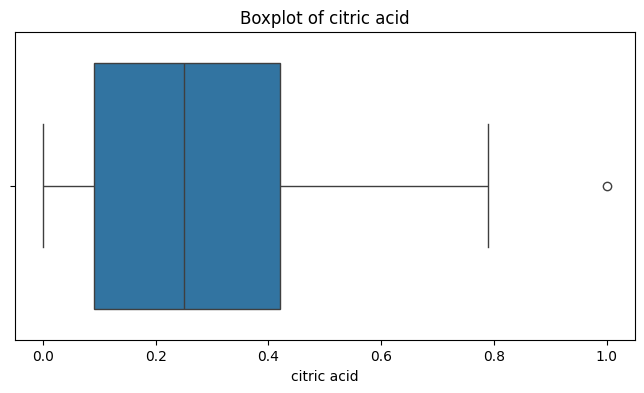

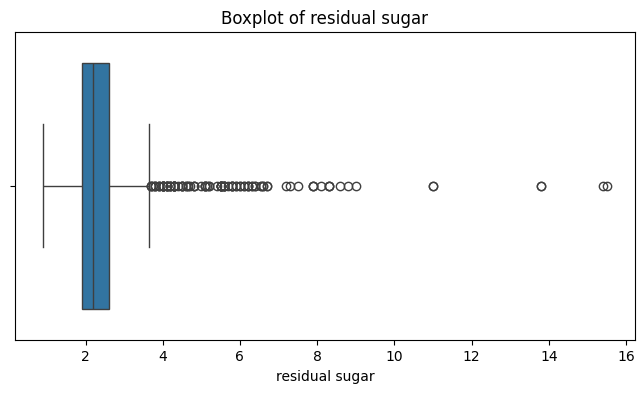

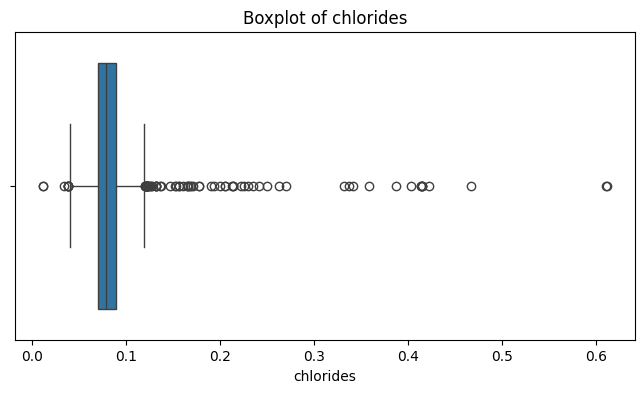

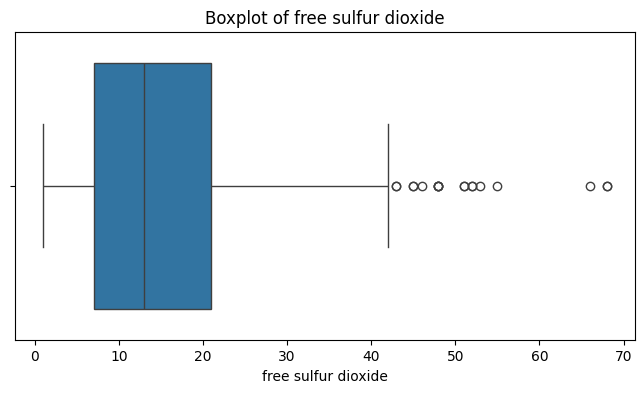

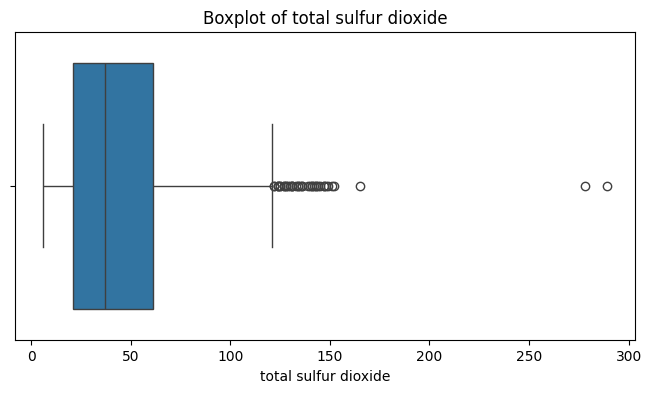

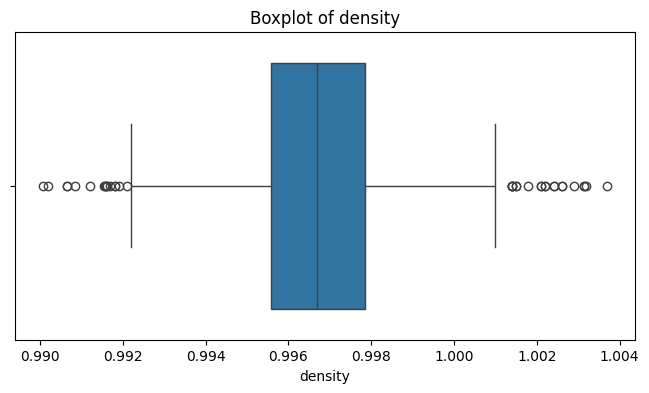

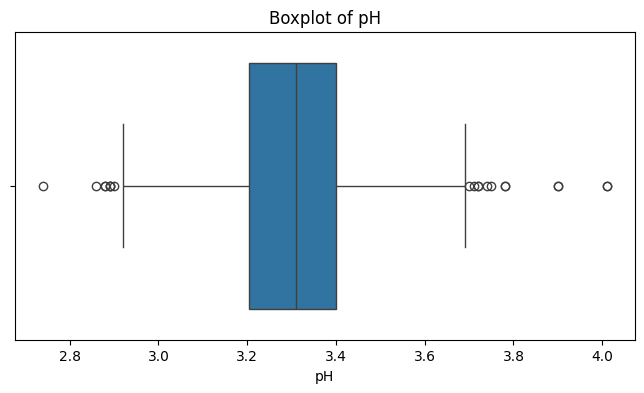

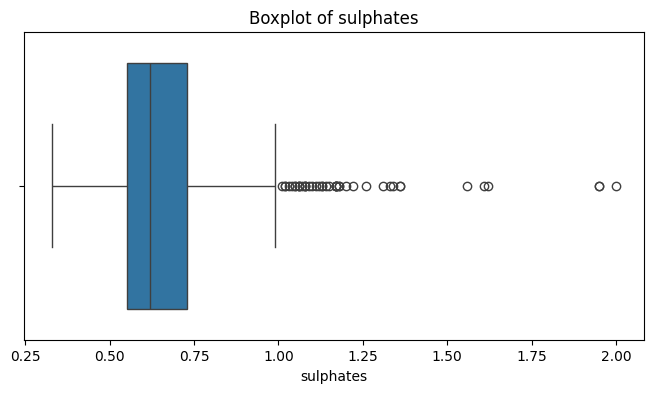

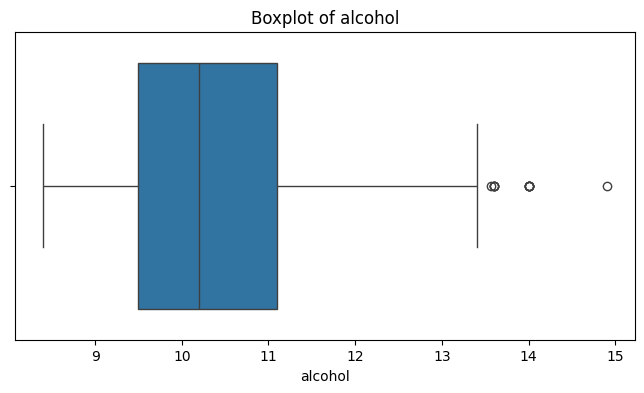

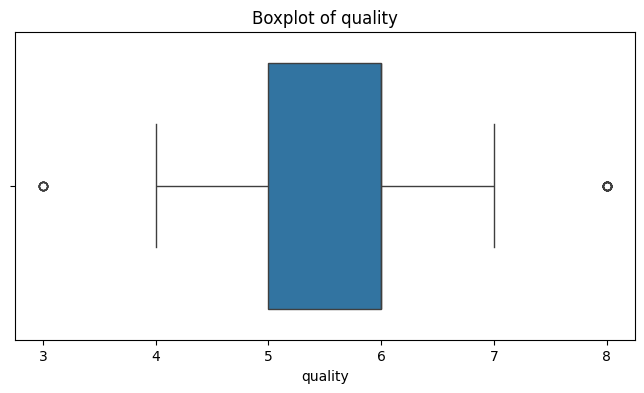

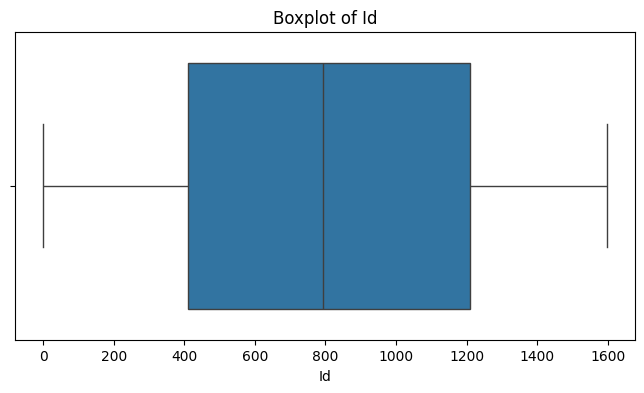

In [ ]:
# Boxplot-Outlier Ananlysis
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
# Detect outliers for every feature
features=df.drop(columns=["quality"])

#Calculate Q1 and Q3
Q1=features.quantile(0.25)
Q3=features.quantile(0.75)

# Calculate IQR
IQR=Q3-Q1

#Calculate Lower and Upper Limits
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

# Detect Outliers
outlier_mask=(features<lower_bound) | (features>upper_bound)

#Count outliers for each feature
outlier_count=outlier_mask.sum()

#Percentage of Outliers
outlier_percentage=(outlier_count/len(features))*100

#Create Summary table
outlier_summary=pd.DataFrame({
    'Q1':Q1,
    'Q3':Q3,
    'IQR':IQR,
    'lower bound':lower_bound,
    'upper bound':upper_bound,
    'Outlier Count':outlier_count,
    'Outlier %':outlier_percentage
})

outlier_summary.round(3)

,Q1,Q3,IQR,lower bound,upper bound,Outlier Count,Outlier %
fixed acidity,7.100,9.100,2.000,4.100,12.100,44,3.850
volatile acidity,0.392,0.640,0.248,0.021,1.011,14,1.225
citric acid,0.090,0.420,0.330,-0.405,0.915,1,0.087
residual sugar,1.900,2.600,0.700,0.850,3.650,110,9.624
chlorides,0.070,0.090,0.020,0.040,0.120,77,6.737
free sulfur dioxide,7.000,21.000,14.000,-14.000,42.000,18,1.575
total sulfur dioxide,21.000,61.000,40.000,-39.000,121.000,40,3.500
density,0.996,0.998,0.002,0.992,1.001,36,3.150
pH,3.205,3.400,0.195,2.913,3.692,20,1.750
sulphates,0.550,0.730,0.180,0.280,1.000,43,3.762


In [ ]:
#No of outliers in each feature

print("Outliers in each feature:\n")

for column in features.columns:
    print(f"{column:25s}:{outlier_count[column]}")

Outliers in each feature:

fixed acidity            :44
volatile acidity         :14
citric acid              :1
residual sugar           :110
chlorides                :77
free sulfur dioxide      :18
total sulfur dioxide     :40
density                  :36
pH                       :20
sulphates                :43
alcohol                  :12
Id                       :0


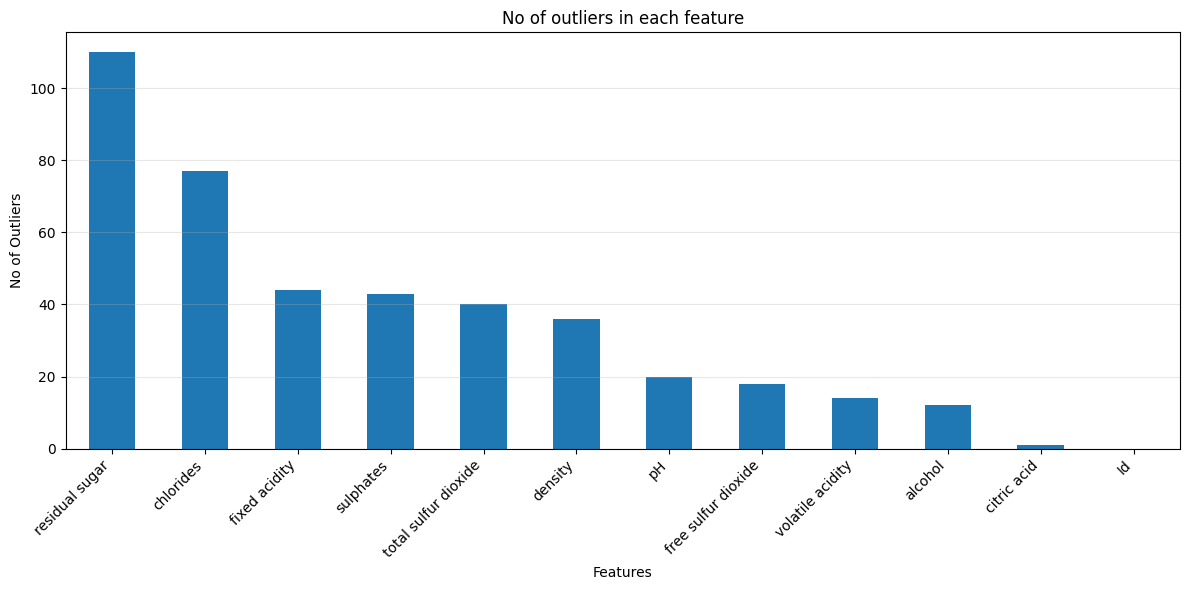

In [ ]:
plt.figure(figsize=(12,6))

outlier_count.sort_values(ascending=False).plot(
    kind='bar'
)

plt.title("No of outliers in each feature")
plt.xlabel("Features")
plt.ylabel("No of Outliers")
plt.xticks(rotation=45,ha='right')
plt.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

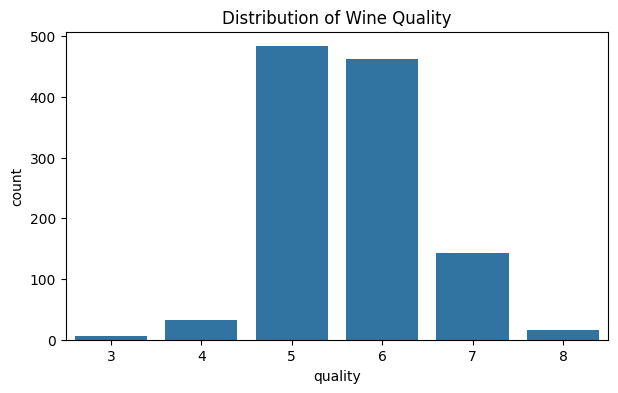

In [ ]:
#Quality Distribution
plt.figure(figsize=(7,4))
sns.countplot(x='quality',data=df)
plt.title("Distribution of Wine Quality")
plt.show()

In [ ]:
df['quality'].value_counts().sort_index()

,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


In [ ]:
df['quality'].value_counts().sort_index()


,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


2.Bivariate Analysis

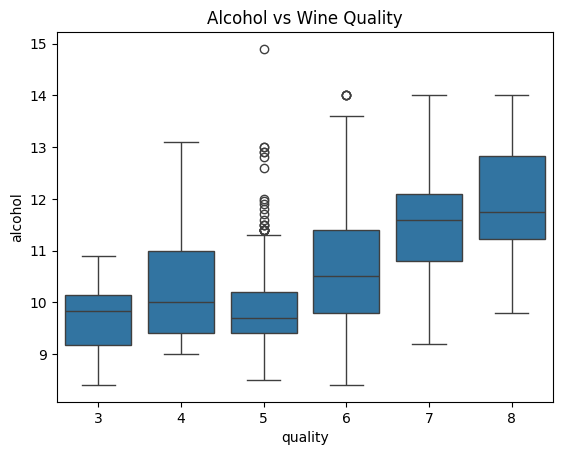

In [ ]:
#Alcohol vs Quality
sns.boxplot(x='quality',y='alcohol',data=df)
plt.title('Alcohol vs Wine Quality')
plt.show()

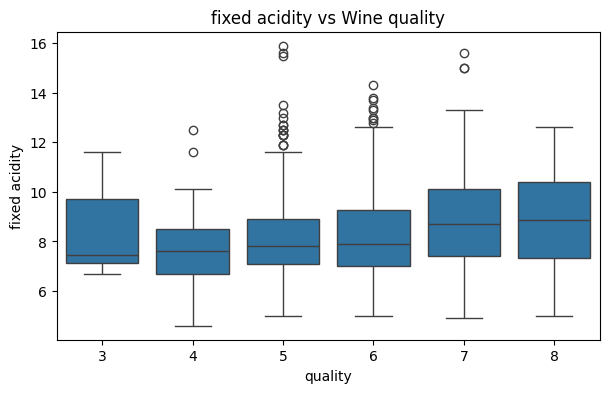

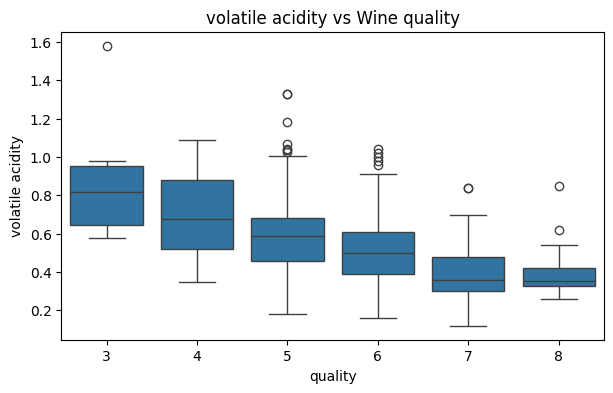

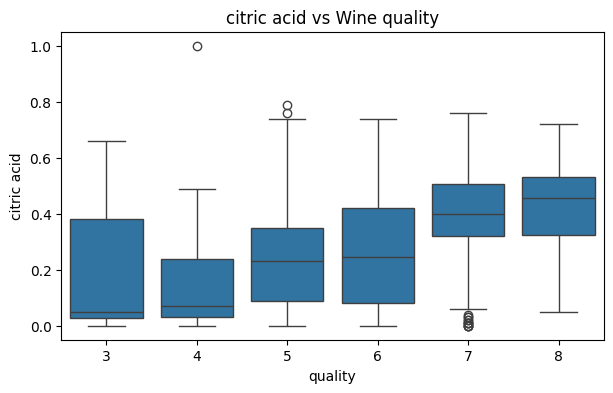

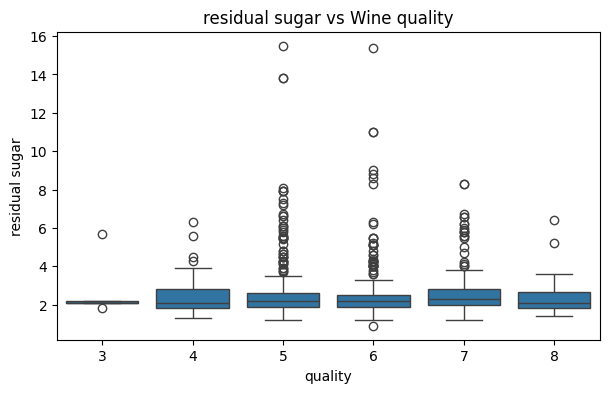

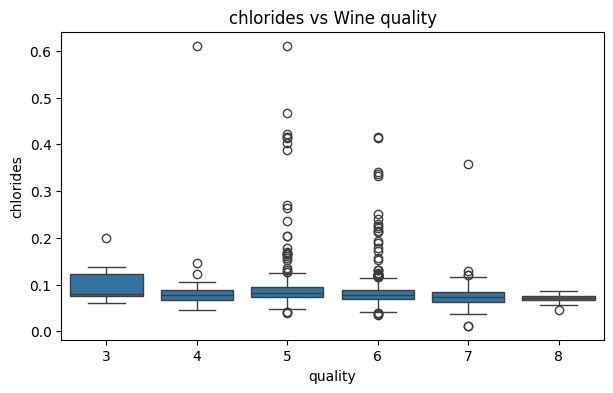

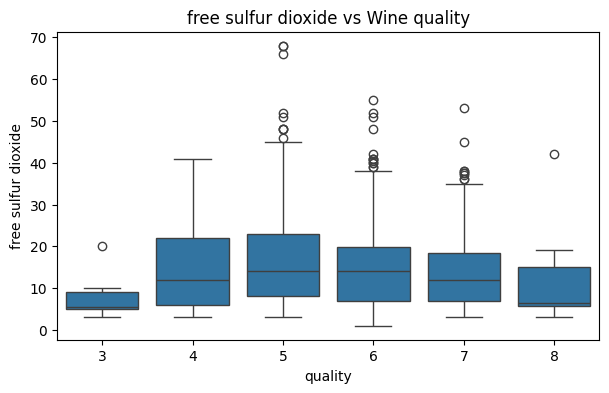

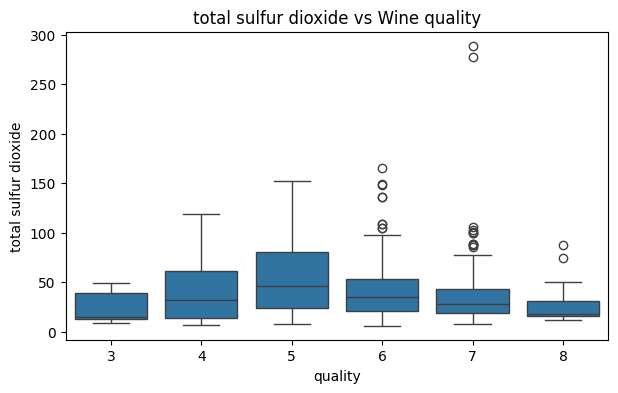

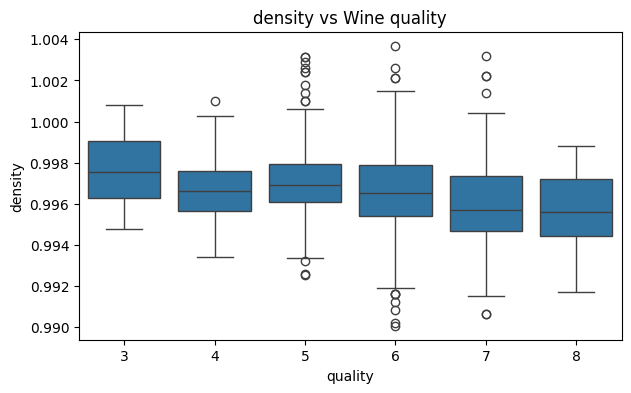

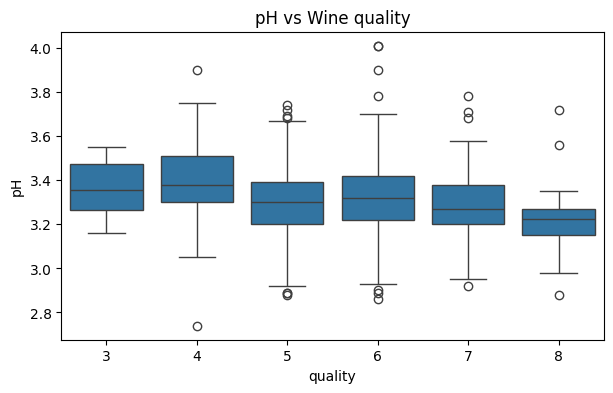

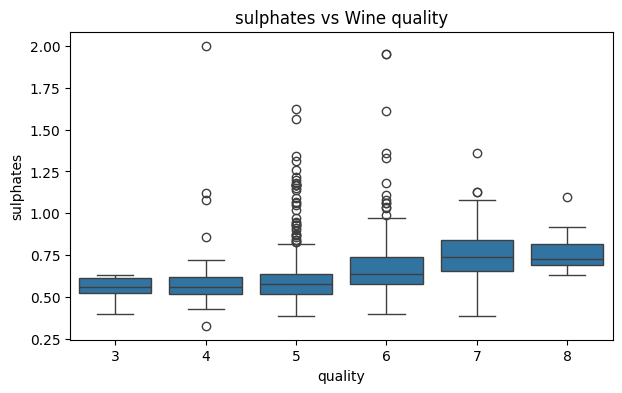

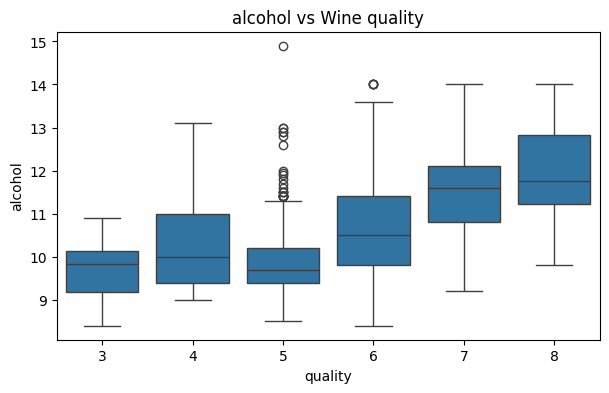

In [ ]:
features=['fixed acidity','volatile acidity','citric acid','residual sugar','chlorides','free sulfur dioxide','total sulfur dioxide',
          'density','pH','sulphates','alcohol']

for col in features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='quality',y=col,data=df)
    plt.title(f'{col} vs Wine quality')
    plt.show()

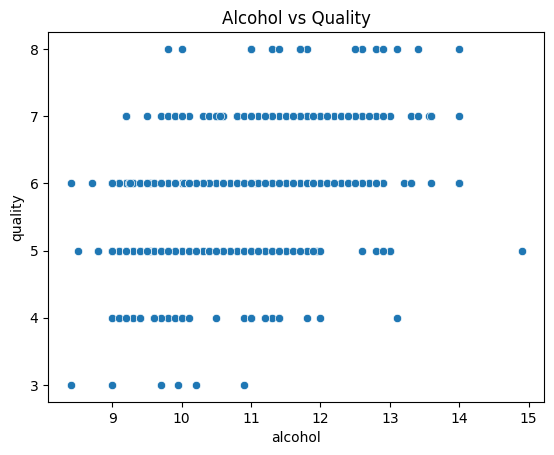

In [ ]:
#Scatter Plot
sns.scatterplot(x='alcohol',y='quality',data=df)
plt.title('Alcohol vs Quality')
plt.show()

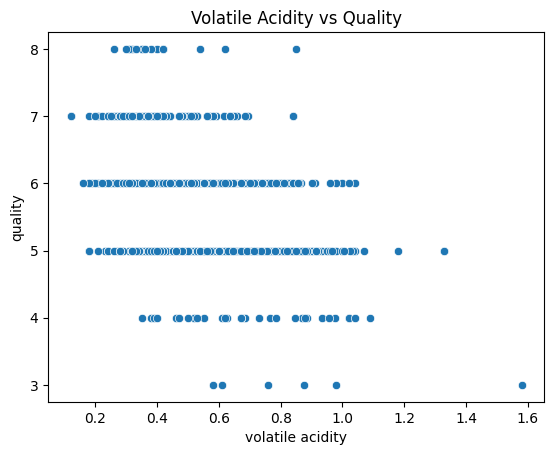

In [ ]:
sns.scatterplot(x='volatile acidity',y='quality',data=df)
plt.title('Volatile Acidity vs Quality')
plt.show()

3.Multivariate Analysis

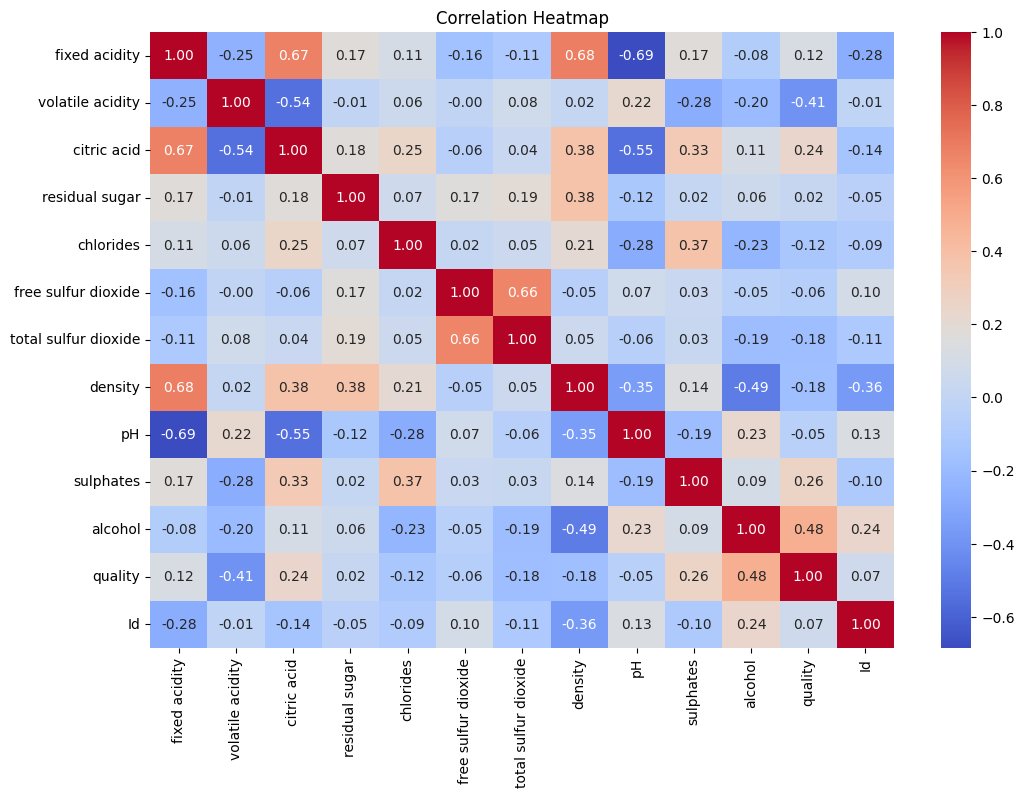

In [ ]:
plt.figure(figsize=(12,8))

corr=df.corr()

sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

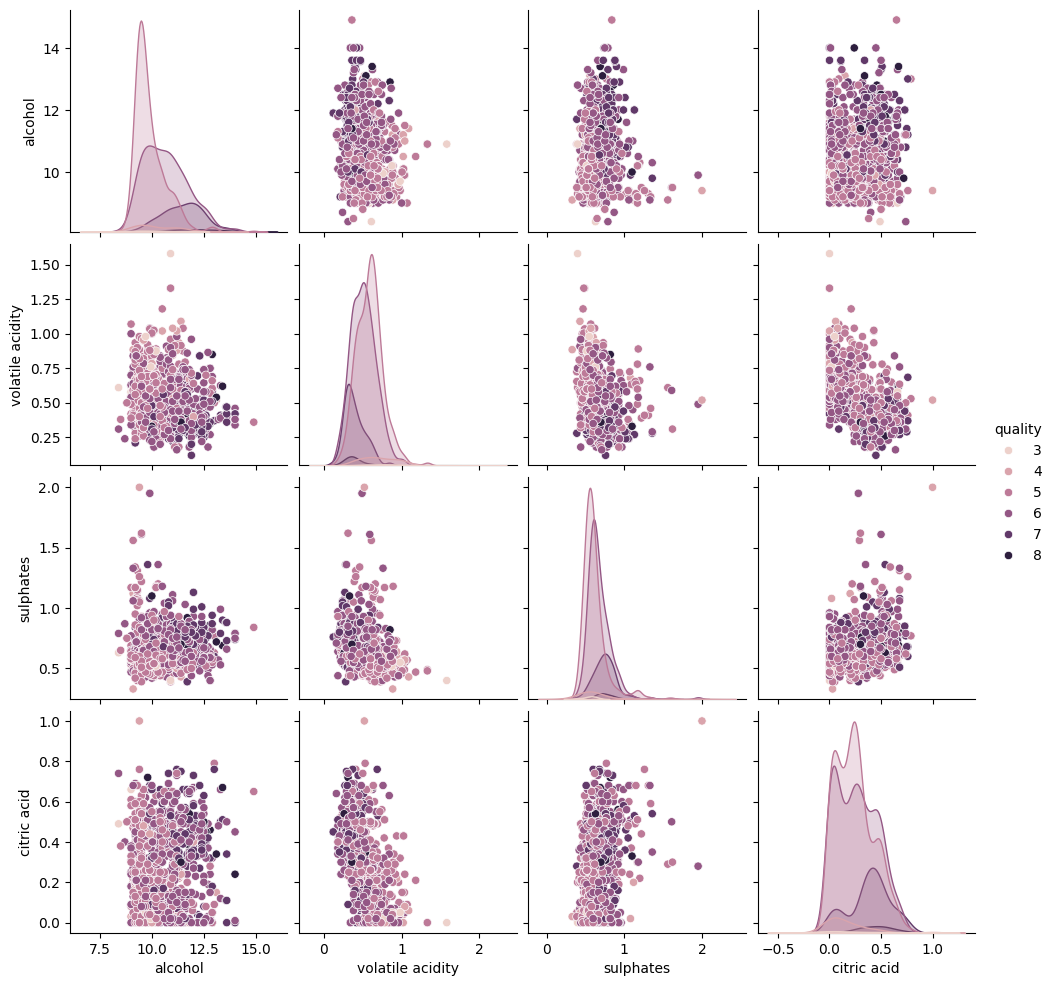

In [ ]:
# Pair Plot
selected=['alcohol','volatile acidity','sulphates','citric acid','quality']

sns.pairplot(df[selected],hue='quality')

plt.show()

In [ ]:
#Multivariate Ananlysis Using Quality Groups
df['quality_group']=pd.cut(
    df['quality'],
    bins=[0,5,6,10],
    labels=['Low','Medium','High']
)

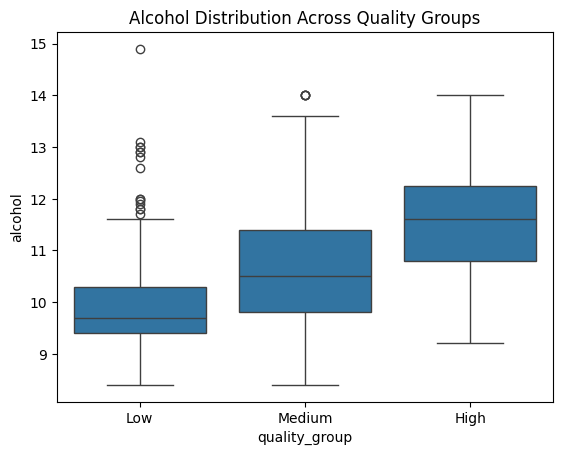

In [ ]:
sns.boxplot(
    x='quality_group',
    y='alcohol',
    data=df
)

plt.title('Alcohol Distribution Across Quality Groups')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                              f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

In [ ]:
X=df.drop('quality',axis=1)
y=df['quality']

In [ ]:
print(y.value_counts())

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,
                                               random_state=42,
                                               stratify=y
                                              )

In [ ]:
criterion='entropy'

In [ ]:
dt_model=DecisionTreeClassifier(
    criterion='entropy',
    random_state=42)

In [ ]:
df['quality_group']=pd.cut(
    df['quality'],
    bins=[0,5,6,10],
    labels=['Low','Medium','High']
)

In [ ]:
print(X.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'Id', 'quality_group'],
      dtype='object')


In [ ]:
print(X.select_dtypes(exclude='number').columns)

Index(['quality_group'], dtype='object')


In [ ]:
y=df['quality']

In [ ]:
X=df.drop(columns=['quality','quality_group'],errors='ignore')

In [ ]:
print(X.columns)
print(X.dtypes)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'Id'],
      dtype='object')
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
Id                        int64
dtype: object


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,
                                               random_state=42,
                                               stratify=y
                                              )

In [ ]:
dt_model=DecisionTreeClassifier(criterion='entropy',random_state=42)

dt_model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
y_train_pred=dt_model.predict(X_train)
y_test_pred=dt_model.predict(X_test)

In [ ]:
train_accuracy=accuracy_score(y_train,y_train_pred)

print("Training Accuracy:",train_accuracy)

Training Accuracy: 1.0


In [ ]:
test_accuracy=accuracy_score(y_test,y_test_pred)

print("Testing Accuracy:",test_accuracy)

Testing Accuracy: 0.6200873362445415


In [ ]:
print("Precision:",
      precision_score(y_test,y_test_pred,average='weighted'))
print("Recall:",
      recall_score(y_test,y_test_pred,average='weighted'))
print("F1 Score:",
      f1_score(y_test,y_test_pred,average='weighted'))

Precision: 0.6070017244204808
Recall: 0.6200873362445415
F1 Score: 0.6099421427959831


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.20      0.14      0.17         7
           5       0.69      0.80      0.74        97
           6       0.62      0.52      0.56        92
           7       0.48      0.52      0.50        29
           8       0.00      0.00      0.00         3

    accuracy                           0.62       229
   macro avg       0.33      0.33      0.33       229
weighted avg       0.61      0.62      0.61       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


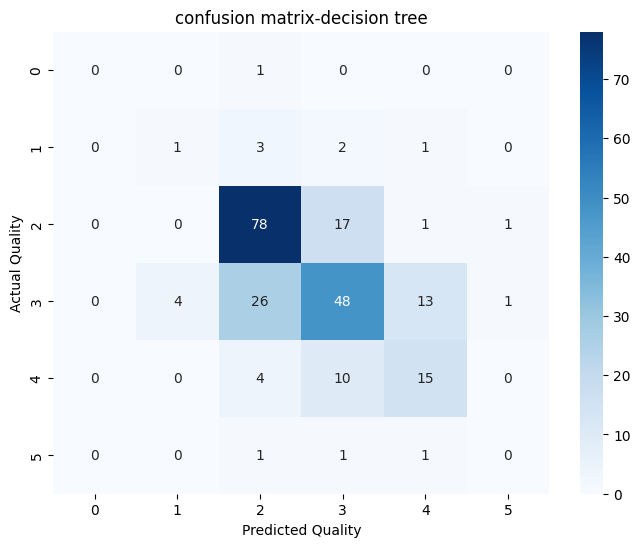

In [ ]:
cm=confusion_matrix(y_test,y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.title('confusion matrix-decision tree')

plt.show()

In [ ]:
print("tree depth:",dt_model.get_depth())
print("number of leaves:",dt_model.get_n_leaves())


tree depth: 18
number of leaves: 236


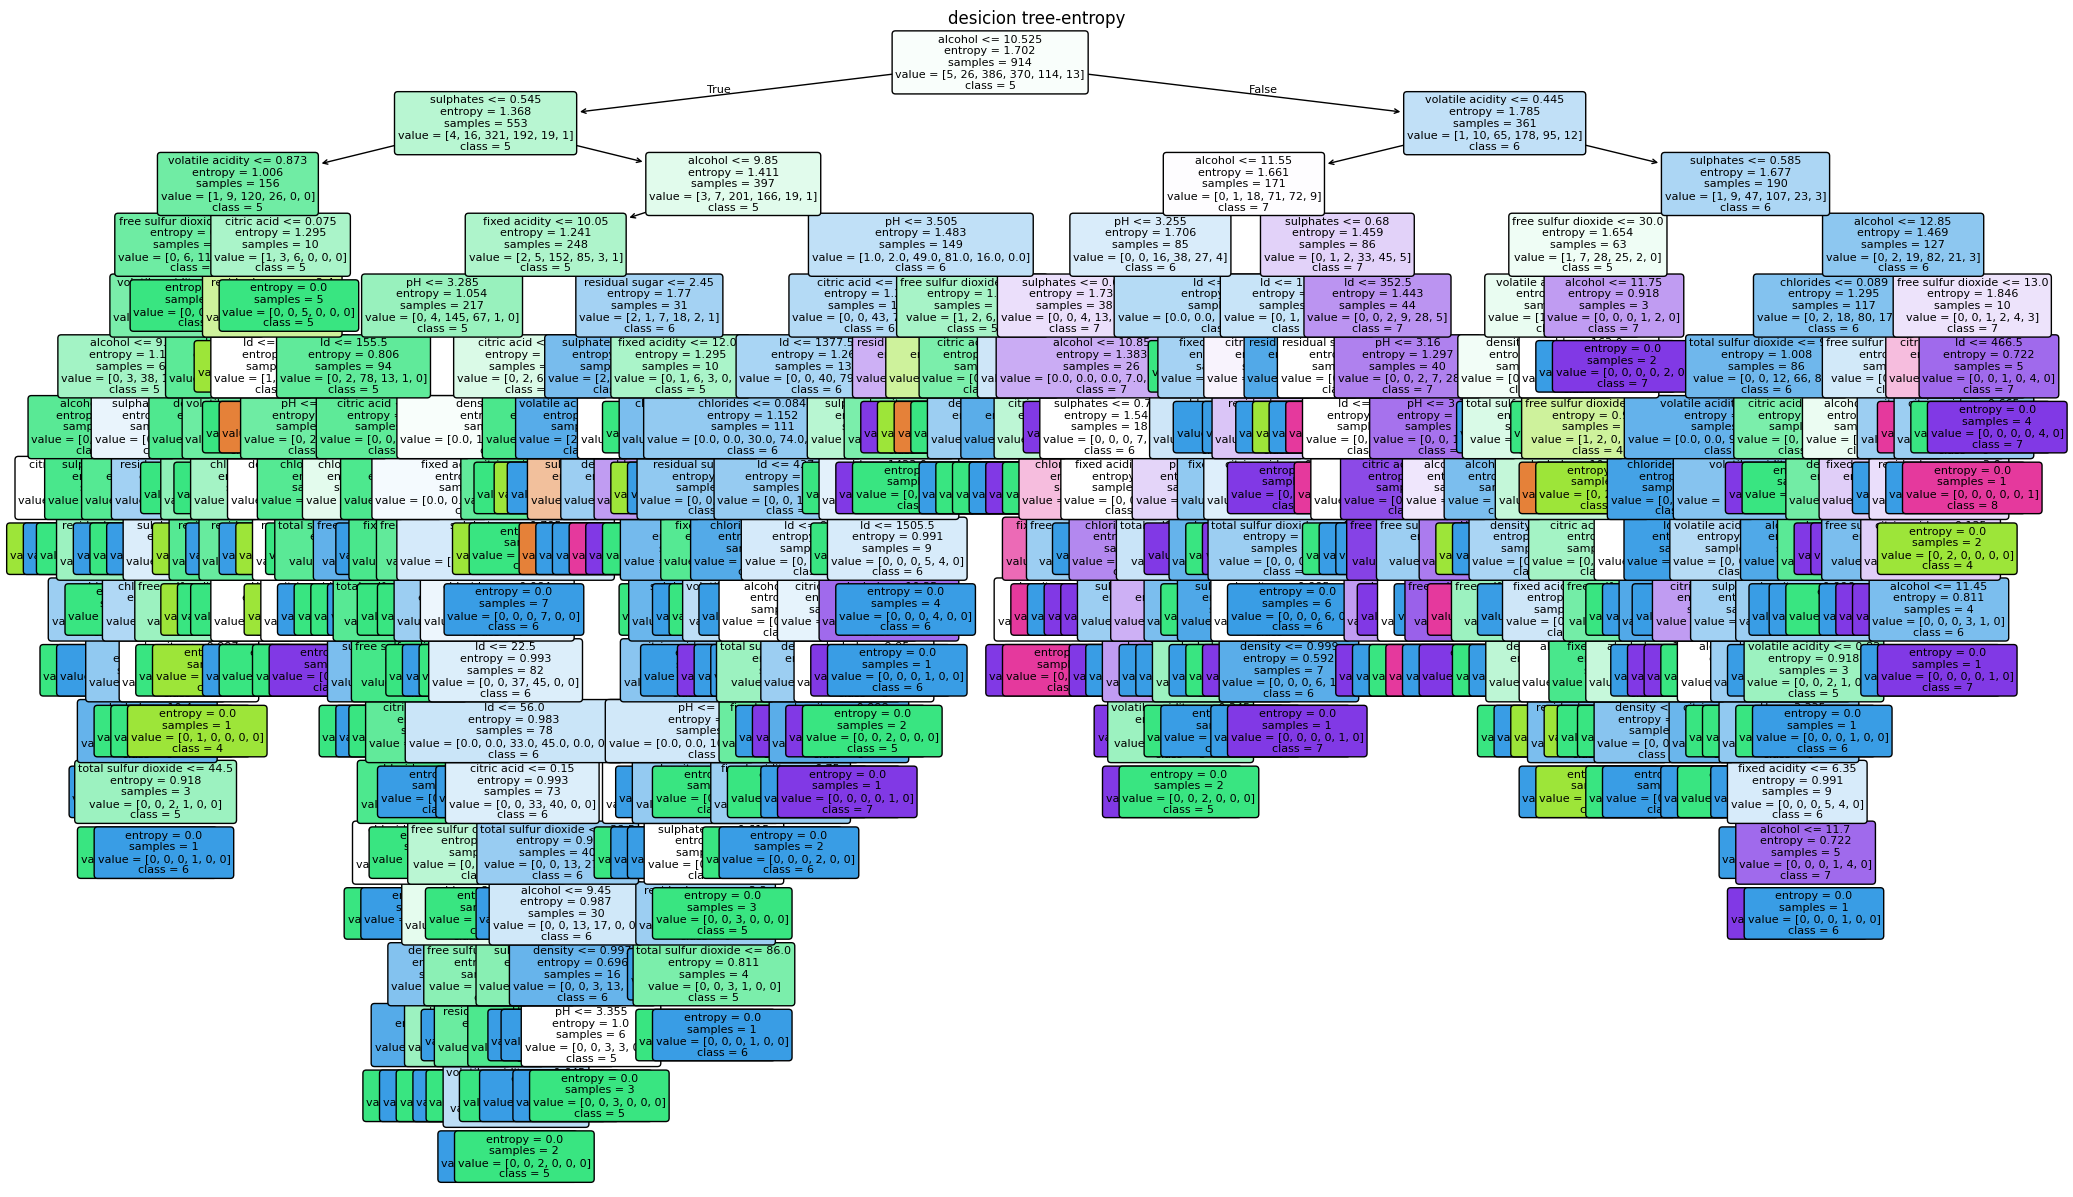

In [ ]:
plt.figure(figsize=(25,15))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("desicion tree-entropy")
plt.show()

Text(0.5, 1.0, 'desicion tree- top 3 levels')

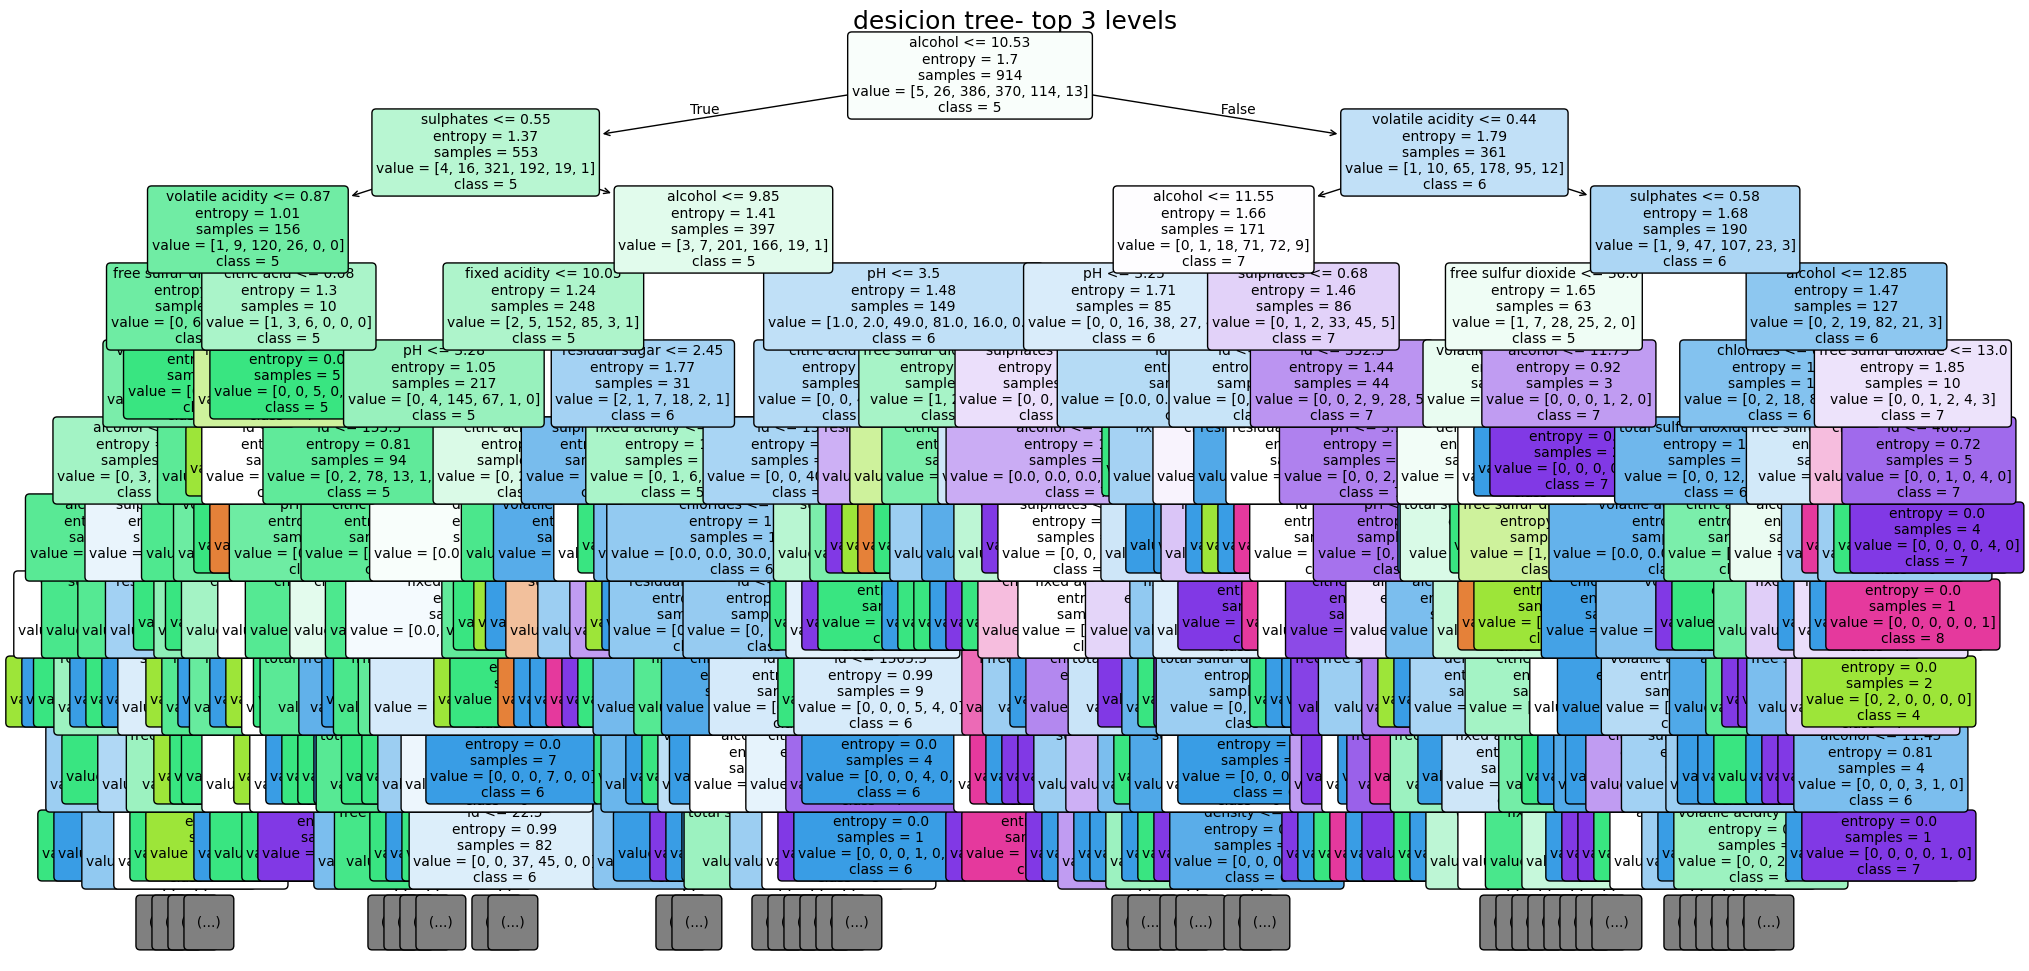

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24,12))


plot_tree(dt_model,feature_names=X.columns,
          class_names=[str(c) for c in sorted(y.unique())],filled=True,
          rounded=True,
          impurity=True,precision=2,fontsize=10,max_depth=10
          )

plt.title("desicion tree- top 3 levels" , fontsize=18)

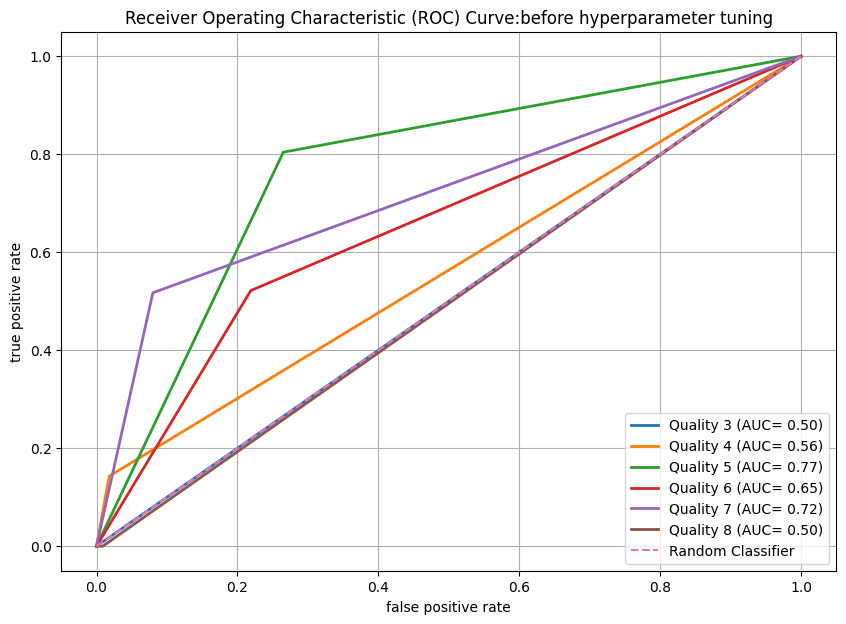

overall auc-roc before tuning 0.7045


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve,auc,roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

classes=sorted(y_test.unique())

y_test_bin= label_binarize(y_test,classes=classes)
y_score=dt_model.predict_proba(X_test)

plt.figure(figsize=(10,7))

for i,class_label in enumerate(classes):
  fpr, tpr, thresholds = roc_curve(y_test_bin[: , i],y_score[:, i])
  roc_auc=auc(fpr,tpr)
  plt.plot(fpr,tpr,linewidth=2,label=f'Quality {class_label} (AUC= {roc_auc:.2f})')

plt.plot([0,1],[0,1],linestyle='--',label='Random Classifier')

plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('Receiver Operating Characteristic (ROC) Curve:before hyperparameter tuning')
plt.legend()
plt.grid()
plt.show()

overall_auc_before = roc_auc_score( y_test_bin,y_score,multi_class='ovr',
                                   average='weighted')
print('overall auc-roc before tuning', round(overall_auc_before,4))

hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

param_grid={
    'criterion':['entropy'],
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10,20],
    'min_samples_leaf':[1,2,4,8],
    'max_features':[None,'sqrt','log2'],
    'ccp_alpha': [0.001,0.01,0.05 ]
}

grid=GridSearchCV(DecisionTreeClassifier(random_state=42),param_grid,cv=5,scoring='accuracy',n_jobs=-1)

grid.fit(X_train,y_train)

print("best parameters")
print(grid.best_params_)

print("best cross validation accuracy")
print(grid.best_score_)

best_tree=grid.best_estimator_





best parameters
{'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 20}
best cross validation accuracy
0.5787785984507295


In [ ]:
y_pred=best_tree.predict(X_test)

print(classification_report(y_test,y_pred))
print("accuracy =",accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.72      0.73      0.72        97
           6       0.56      0.66      0.61        92
           7       0.35      0.24      0.29        29
           8       0.00      0.00      0.00         3

    accuracy                           0.61       229
   macro avg       0.27      0.27      0.27       229
weighted avg       0.57      0.61      0.59       229

accuracy = 0.6069868995633187


In [ ]:
train_accuracy= best_tree.score(X_train,y_train)
test_accuracy= best_tree.score(X_test,y_test)

print("Training Accuracy:",train_accuracy)
print("Testing Accuracy:",test_accuracy)

Training Accuracy: 0.6903719912472648
Testing Accuracy: 0.6069868995633187


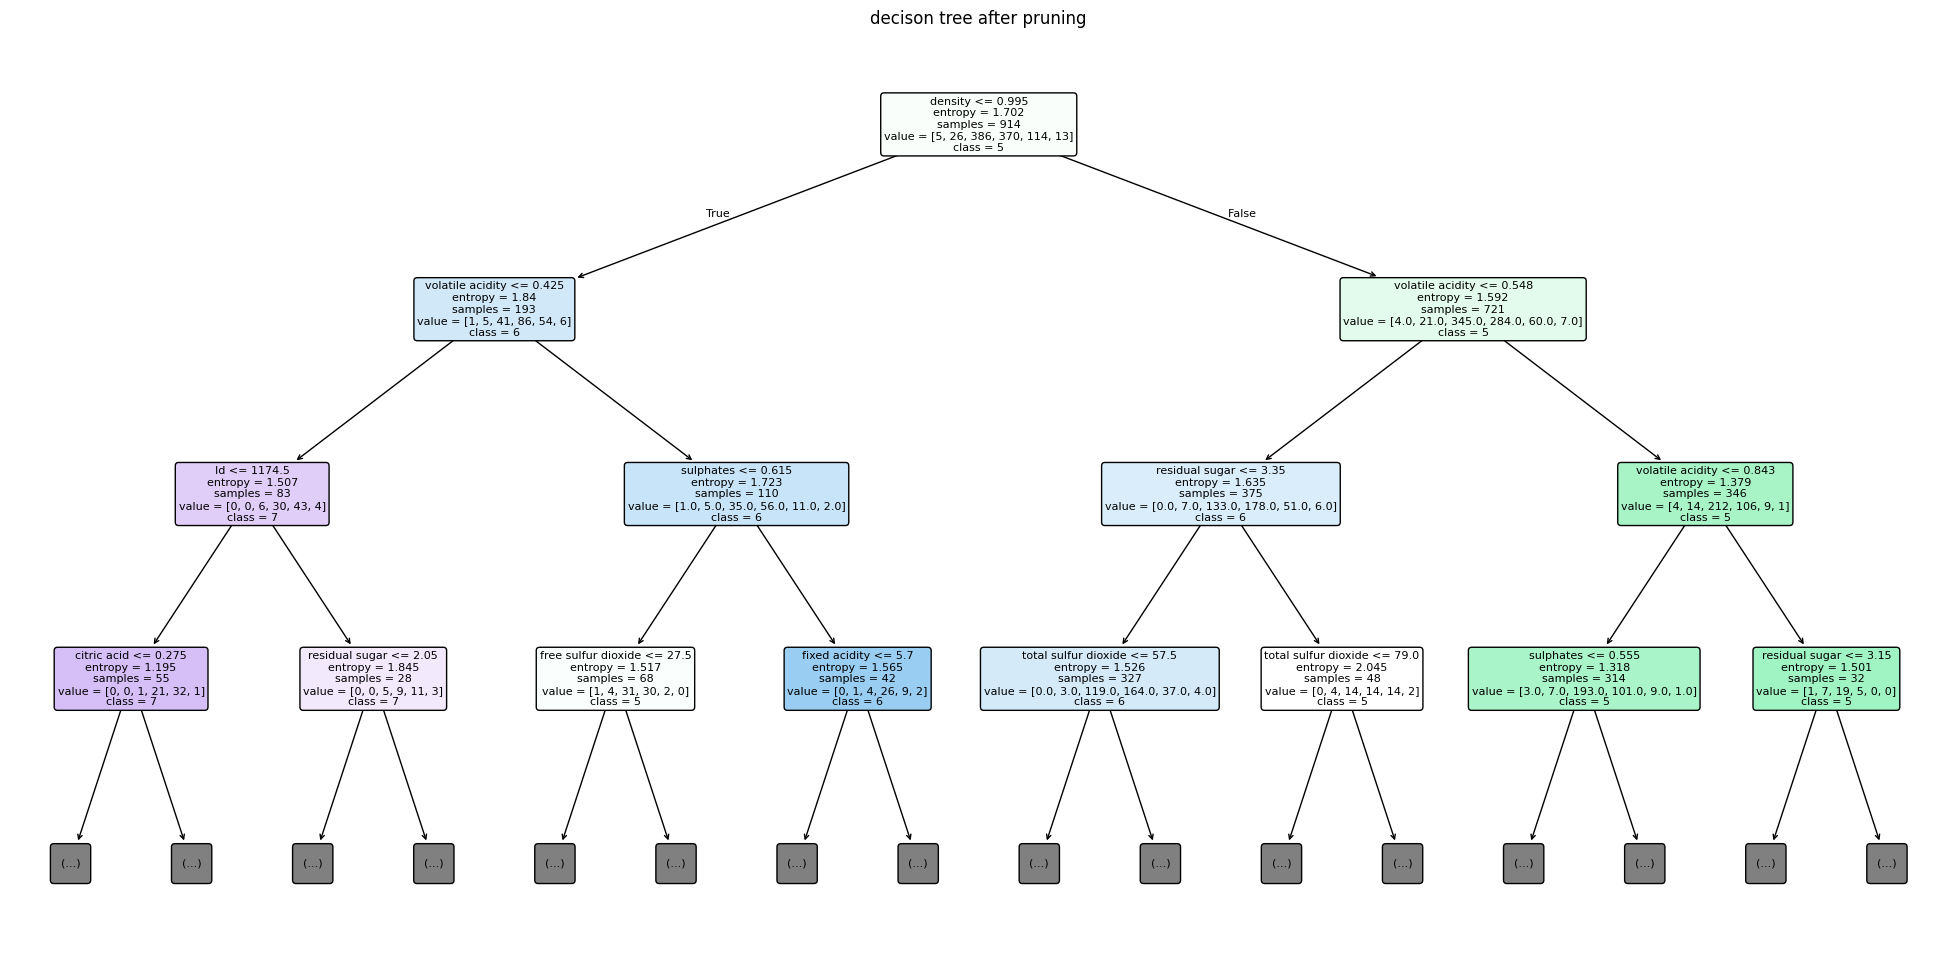

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,12))

plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=[str(c) for c in best_tree.classes_],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("decison tree after pruning")
plt.show()

cross validation

In [ ]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(best_tree,X,y,cv=10,scoring='accuracy')

print(scores)

print("average accuracy=",scores.mean())

print("std=",scores.std())

[0.46086957 0.60869565 0.53913043 0.44736842 0.53508772 0.59649123
 0.44736842 0.54385965 0.44736842 0.46491228]
average accuracy= 0.5091151792524791
std= 0.060044177936138456


learning curve

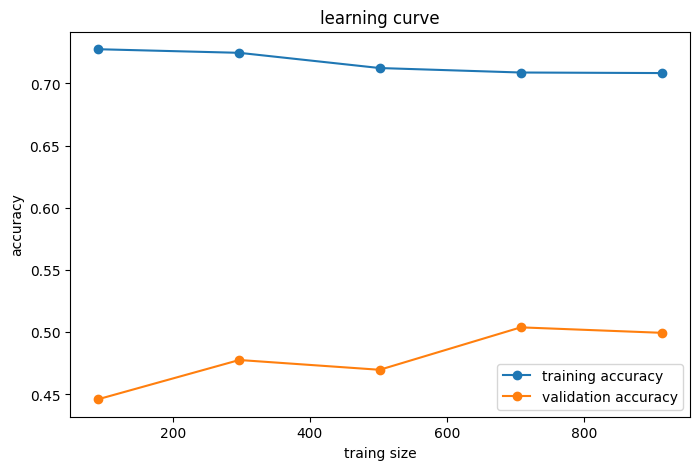

In [ ]:
from sklearn.model_selection import learning_curve
train_sizes,train_scores,test_scores = learning_curve(best_tree,X,y,cv=5,scoring='accuracy')
plt.figure(figsize=(8,5))
plt.plot(train_sizes,train_scores.mean(axis=1),marker='o',label='training accuracy')
plt.plot(train_sizes,test_scores.mean(axis=1),marker='o',label='validation accuracy')

plt.xlabel("traing size")
plt.ylabel("accuracy")
plt.title("learning curve")

plt.legend()
plt.show()

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_group
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,Low
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,Low
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,Low
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,Medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,Low


In [ ]:
new_wine = pd.DataFrame([{
    'Id':1,
    'fixed acidity':7.4,
    'volatile acidity':0.7,
    'citric acid':0.20,
    'residual sugar':2.0,
    'chlorides':0.065,
    'free sulfur dioxide':15.0,
    'total sulfur dioxide':40.0,
    'density':1.29,
    'pH':3.4,
    'sulphates':0.54,
    'alcohol':9.4
}])

new_wine = new_wine[best_tree.feature_names_in_]

prediction = best_tree.predict(new_wine)

print("Predicted wine quality:", prediction[0])

Predicted wine quality: 5
